# Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data Analysis

In [27]:
DEEP_SLEEP = pd.read_csv('https://raw.githubusercontent.com/AccountdiSupporto/IoT_Support/refs/heads/main/deep_sleep.csv')
SENDER = pd.read_csv('https://raw.githubusercontent.com/AccountdiSupporto/IoT_Support/refs/heads/main/sender.csv')
SENSOR_READ = pd.read_csv('https://raw.githubusercontent.com/AccountdiSupporto/IoT_Support/refs/heads/main/sensor-read.csv')

In [28]:
DEEP_SLEEP

,Timestamp,Data
0,2026-03-15 12:37:41.628465,45.36
1,2026-03-15 12:37:41.678682,45.64
2,2026-03-15 12:37:41.728202,45.64
3,2026-03-15 12:37:41.778712,45.50
4,2026-03-15 12:37:41.828135,45.78
...,...,...
1526,2026-03-15 12:38:57.903844,45.50
1527,2026-03-15 12:38:57.953062,45.64
1528,2026-03-15 12:38:58.003127,45.14
1529,2026-03-15 12:38:58.052930,45.64


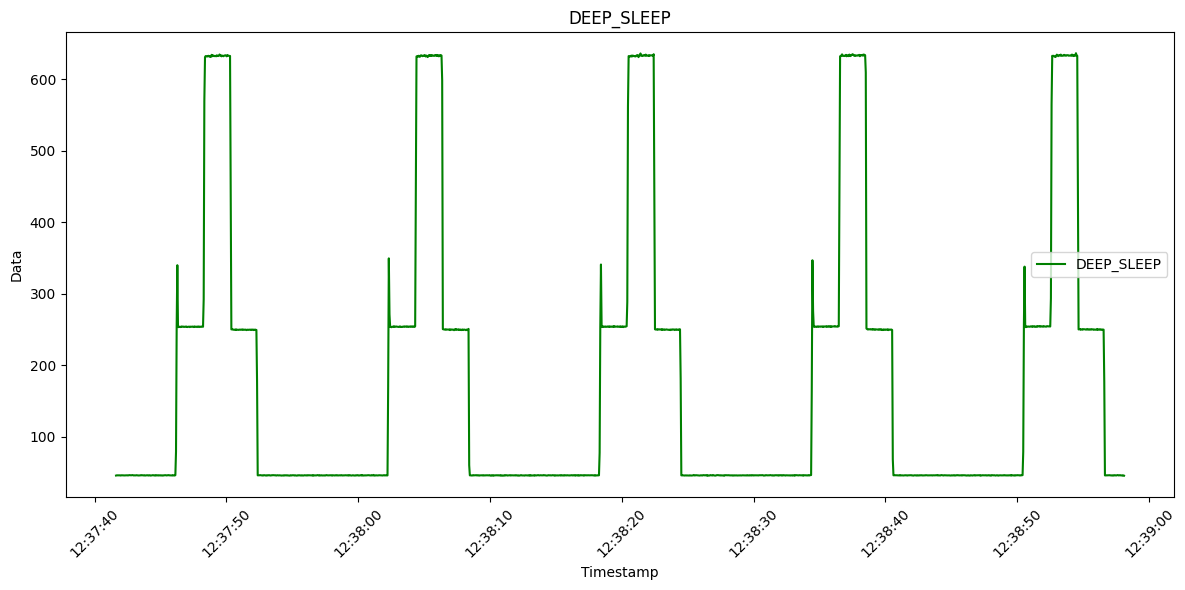

In [29]:
DEEP_SLEEP['Timestamp'] = pd.to_datetime(DEEP_SLEEP['Timestamp'])

plt.figure(figsize=(12, 6))

plt.plot(DEEP_SLEEP['Timestamp'], DEEP_SLEEP['Data'], color='g', label="DEEP_SLEEP")

plt.xlabel('Timestamp')
plt.ylabel('Data')
plt.title('DEEP_SLEEP')

plt.savefig('DEEP_SLEEP.pdf', format='pdf', bbox_inches='tight')

plt.xticks(rotation=45)

plt.legend()
plt.tight_layout() # Ensures nothing gets cut off at the edges
plt.show()

In [30]:
SENDER

,Timestamp,Data
0,2026-03-15 12:27:38.803023,605.18
1,2026-03-15 12:27:38.852467,605.02
2,2026-03-15 12:27:38.902781,605.89
3,2026-03-15 12:27:38.953113,606.07
4,2026-03-15 12:27:39.002703,605.56
...,...,...
1389,2026-03-15 12:28:48.245574,606.96
1390,2026-03-15 12:28:48.295863,605.50
1391,2026-03-15 12:28:48.345360,606.40
1392,2026-03-15 12:28:48.395663,606.71


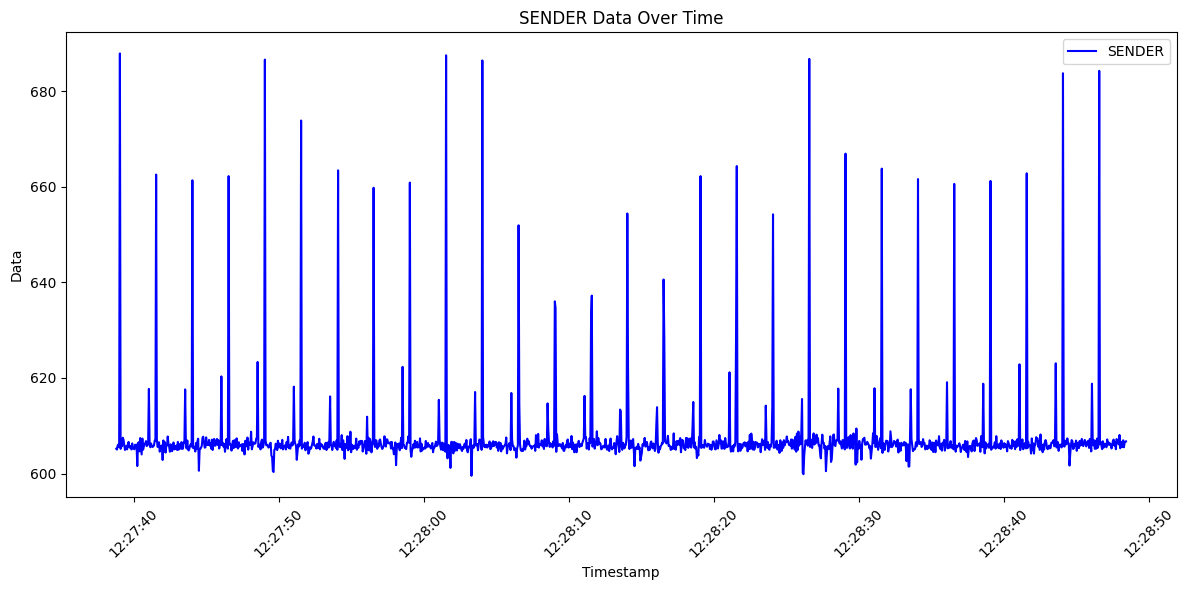

In [31]:
SENDER['Timestamp'] = pd.to_datetime(SENDER['Timestamp'])

# 2. Create the figure
plt.figure(figsize=(12, 6))

# 3. Plot the data using a line plot (changed color to blue 'b')
plt.plot(SENDER['Timestamp'], SENDER['Data'], color='b', label="SENDER")

# (Optional) If you want a bar chart instead, use this:
# plt.bar(SENDER['Timestamp'], SENDER['Data'], color='b', width=0.00001, label="SENDER")

# 4. Add your labels and title
plt.xlabel('Timestamp')
plt.ylabel('Data')
plt.title('SENDER Data Over Time')

plt.savefig('SENDER Data Over Time.pdf', format='pdf', bbox_inches='tight')


# 5. Rotate the x-axis labels to keep them readable
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

In [32]:
SENSOR_READ

,Timestamp,Data
0,2026-03-15 12:42:00.750580,236.51
1,2026-03-15 12:42:00.800857,236.79
2,2026-03-15 12:42:00.849904,237.49
3,2026-03-15 12:42:00.900316,235.43
4,2026-03-15 12:42:00.949804,236.87
...,...,...
1028,2026-03-15 12:42:52.138334,237.71
1029,2026-03-15 12:42:52.188122,237.35
1030,2026-03-15 12:42:52.238496,236.71
1031,2026-03-15 12:42:52.287990,237.82


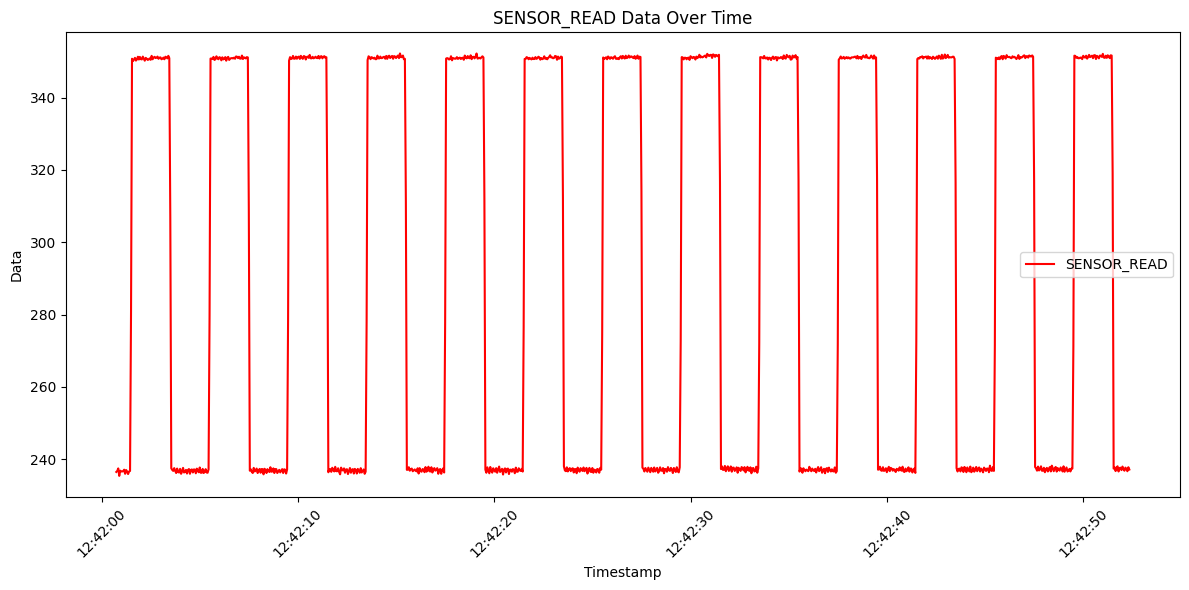

In [33]:
SENSOR_READ['Timestamp'] = pd.to_datetime(SENSOR_READ['Timestamp'])

plt.figure(figsize=(12, 6))

plt.plot(SENSOR_READ['Timestamp'], SENSOR_READ['Data'], color='r', label="SENSOR_READ")

plt.xlabel('Timestamp')
plt.ylabel('Data')
plt.title('SENSOR_READ Data Over Time')

plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

# Power consumption


## Sensor reading

Here we are going to calculate the Sensor Reading power consumption by computing the mean of the values seen in the CSV. We didn't measure the idle power consumption between measurements since our sensors measure one time between each cycle.

In [34]:
sensing = SENSOR_READ[SENSOR_READ['Data'] > 300]['Data'].mean()

print(f"Mean power consumption during Sensing phase: {sensing:.2f}")

Mean power consumption during Sensing phase: 350.16


## Deep Sleep

Here we are going to calculate the power consumption of the sytsem when it is in deep sleep, when the Wi-fi is on and when the Wi-fi is off (idle phase)



In [35]:
deepsleep = DEEP_SLEEP[DEEP_SLEEP['Data'] < 100 ]['Data'].mean()
wifi_on = DEEP_SLEEP[DEEP_SLEEP['Data'] > 500 ]['Data'].mean()
wifi_off_idle = DEEP_SLEEP[(DEEP_SLEEP['Data'] > 200) & (DEEP_SLEEP['Data'] < 300) ]['Data'].mean()
boot = DEEP_SLEEP[(DEEP_SLEEP['Data'] > 300) & (DEEP_SLEEP['Data'] < 400) ]['Data'].mean()

print(f"Mean power consumption during Deep Sleep phase: {deepsleep:.2f}")
print(f"Mean power consumption during Wi-Fi on phase: {wifi_on:.2f}")
print(f"Mean power consumption during Wi-Fi off phase: {wifi_off_idle:.2f}")
print(f"Mean power consumption during Boot phase: {boot:.2f}")

Mean power consumption during Deep Sleep phase: 45.78
Mean power consumption during Wi-Fi on phase: 632.04
Mean power consumption during Wi-Fi off phase: 252.22
Mean power consumption during Boot phase: 342.98


## Boot phase


Here we are going to calculate the Boot time by analysing the values seen in the CSV

In [36]:
from datetime import datetime


#CASO1: FASI STABILI INCLUSE
starting_boot = "2026-03-15 12:37:46.128069" #taken from Deep Sleep CSV
ending_boot = "2026-03-15 12:37:46.327682" #taken from Deep Sleep CSV

#CASO2: FASI INSTABILI INCLUES
#starting_boot = "2026-03-15 12:37:46.177419" #taken from Deep Sleep CSV
#ending_boot = "2026-03-15 12:37:46.277652" #taken from Deep Sleep CSV

dt2 = datetime.strptime(ending_boot, "%Y-%m-%d %H:%M:%S.%f")
dt1 = datetime.strptime(starting_boot, "%Y-%m-%d %H:%M:%S.%f")

differenza = dt2 - dt1

print(f"Starting Time: {dt1}")
print(f"Ending Time: {dt2}")
print(f"Boot time: {differenza}")

boot_duration = differenza.total_seconds()
print(f"Boot time in seconds: {boot_duration} s")

Starting Time: 2026-03-15 12:37:46.128069
Ending Time: 2026-03-15 12:37:46.327682
Boot time: 0:00:00.199613
Boot time in seconds: 0.199613 s


## Sender


Here we are going to calculate the power consumption of the system when the Wi-fi is on but not transmitting anything, when it is transmitting at 19.5 dBm and when it is transmitting at 2 dBm

In [37]:
send19 = SENDER[SENDER['Data'] > 640 ]['Data'].mean()
send2 = SENDER[(SENDER['Data'] > 610) & (SENDER['Data'] < 630) ]['Data'].mean()

print(f"Mean power consumption when it is transmitting at 19.5 dBm: {send19:.2f}")
print(f"Mean power consumption when it is transmitting at 2 dBm: {send2:.2f}")

Mean power consumption when it is transmitting at 19.5 dBm: 667.41
Mean power consumption when it is transmitting at 2 dBm: 617.88


To recap this is the power spent for each of the states we considered:

In [38]:
print(f"Mean power consumption during Sensing phase: {sensing:.2f} mW")
print(f"Mean power consumption during Deep Sleep phase: {deepsleep:.2f} mW")
print(f"Mean power consumption during Wi-Fi on phase: {wifi_on:.2f} mW")
print(f"Mean power consumption during the Wi-Fi off idle phase: {wifi_off_idle:.2f} mW")
print(f"Mean power consumption during Boot phase: {boot:.2f} mW")
print(f"Mean power consumption when it is transmitting at 19.5 dBm: {send19:.2f} mW")
print(f"Mean power consumption when it is transmitting at 2 dBm: {send2:.2f} mW")

Mean power consumption during Sensing phase: 350.16 mW
Mean power consumption during Deep Sleep phase: 45.78 mW
Mean power consumption during Wi-Fi on phase: 632.04 mW
Mean power consumption during the Wi-Fi off idle phase: 252.22 mW
Mean power consumption during Boot phase: 342.98 mW
Mean power consumption when it is transmitting at 19.5 dBm: 667.41 mW
Mean power consumption when it is transmitting at 2 dBm: 617.88 mW


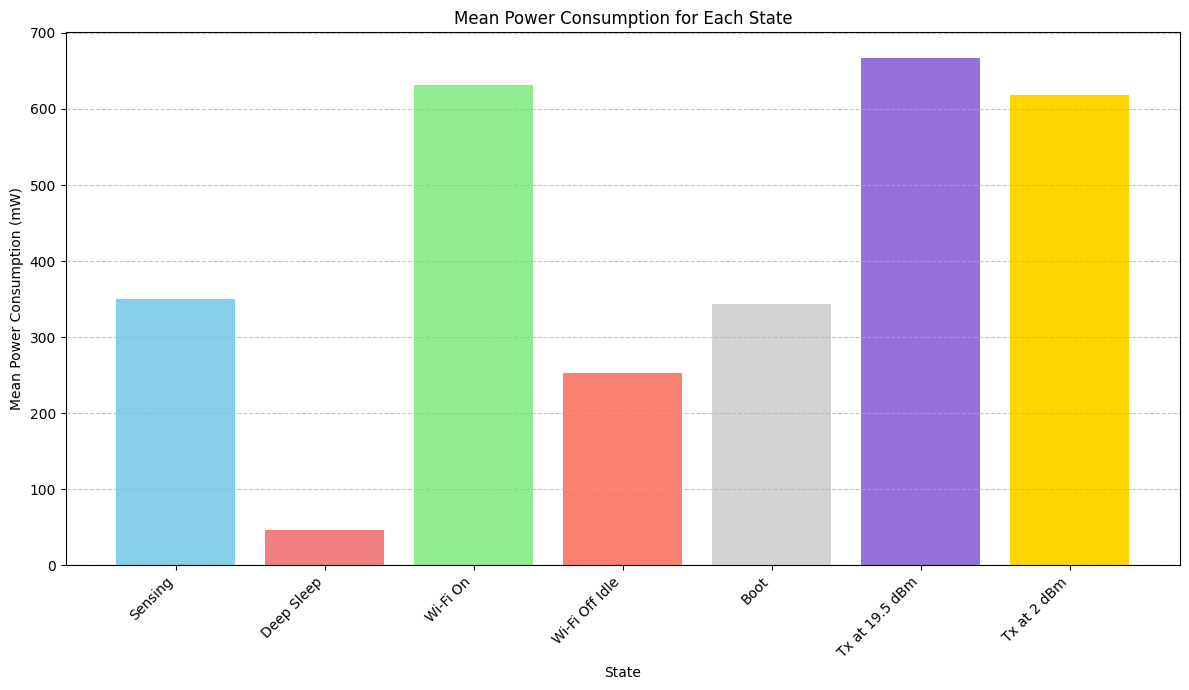

<Figure size 640x480 with 0 Axes>

In [39]:
states = [
    'Sensing',
    'Deep Sleep',
    'Wi-Fi On',
    'Wi-Fi Off Idle',
    'Boot',
    'Tx at 19.5 dBm',
    'Tx at 2 dBm'
]

power_consumption = [
    sensing,
    deepsleep,
    wifi_on,
    wifi_off_idle,
    boot,
    send19,
    send2
]

plt.figure(figsize=(12, 7))
plt.bar(states, power_consumption, color=['skyblue', 'lightcoral', 'lightgreen', 'salmon', 'lightgray', 'mediumpurple', 'gold', 'lightpink', 'darkseagreen'])
plt.xlabel('State')
plt.ylabel('Mean Power Consumption (mW)')
plt.title('Mean Power Consumption for Each State')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.savefig('Mean Power Consumption for Each State.pdf', format='pdf', bbox_inches='tight')

# Energy consumption

To calculate the energy consumption we have to simulate the functioning of our system and with the micros() function measure the duration of each state. A simulation gave us an approximation of the duration of each state in our implementation. The result is drawn from a csv file containing 28 cycles.

In [40]:
PERSONAL_DATA = pd.read_csv('https://raw.githubusercontent.com/AccountdiSupporto/IoT_Support/refs/heads/main/Simulation_timing.csv')
PERSONAL_DATA

,Sensing duration (us),Wi-Fi On duration (us),Transmission duration (us),Idle duration (Wi-Fi OFF - Part 1) (us),Idle duration (Wi-Fi OFF - Part 2) (us),Total Idle duration (Wi-Fi OFF) (us)
0,1001,72694,65,1012,147,1159
1,1171,72746,65,1089,146,1235
2,1017,73661,77,994,146,1140
3,1005,73669,77,1005,147,1152
4,1000,72695,65,1009,146,1155
5,1018,72244,65,1084,147,1231
6,1002,73669,77,1006,146,1152
7,1006,73663,77,1005,147,1152
8,1019,73254,77,1095,146,1241
9,1003,73670,78,1074,147,1221


In the idle phase after we turned off the wifi we didn't account for the serial printing of the time durations, since that was only necessary for our calculations, and not for the correct functioning of the system.

In [41]:
sensing_duration = PERSONAL_DATA['Sensing duration (us)'].mean()
wifi_on_duration = PERSONAL_DATA['Wi-Fi On duration (us)'].mean()
transmision_duration = PERSONAL_DATA['Transmission duration (us)'].mean()
idle_duration_1 = PERSONAL_DATA['Idle duration (Wi-Fi OFF - Part 1) (us)'].mean()
idle_duration_2 = PERSONAL_DATA['Idle duration (Wi-Fi OFF - Part 2) (us)'].mean()
idle_duration = PERSONAL_DATA['Total Idle duration (Wi-Fi OFF) (us)'].mean()
deep_sleep_duration = 1400000
boot_duration = 199613
print(f"Boot duration: {boot_duration:.2f} µs")
print(f"Sensing duration: {sensing_duration:.2f} µs")
print(f"WiFi on duration: {wifi_on_duration:.2f} µs")
print(f"Transmission duration: {transmision_duration:.2f} µs")
print(f"Part 1 of the Idle duration : {idle_duration_1:.2f} µs")
print(f"Part 2 of the Idle duration : {idle_duration_2:.2f} µs")
print(f"Total Idle duration : {idle_duration:.2f} µs")
print(f"Deep sleep duration: {deep_sleep_duration:.2f} µs")

Boot duration: 199613.00 µs
Sensing duration: 1029.43 µs
WiFi on duration: 73206.75 µs
Transmission duration: 73.57 µs
Part 1 of the Idle duration : 1038.86 µs
Part 2 of the Idle duration : 146.46 µs
Total Idle duration : 1185.32 µs
Deep sleep duration: 1400000.00 µs


Now that we calculated the duration of each state in our simulation, we'll plot the power versus time graph related to our case.

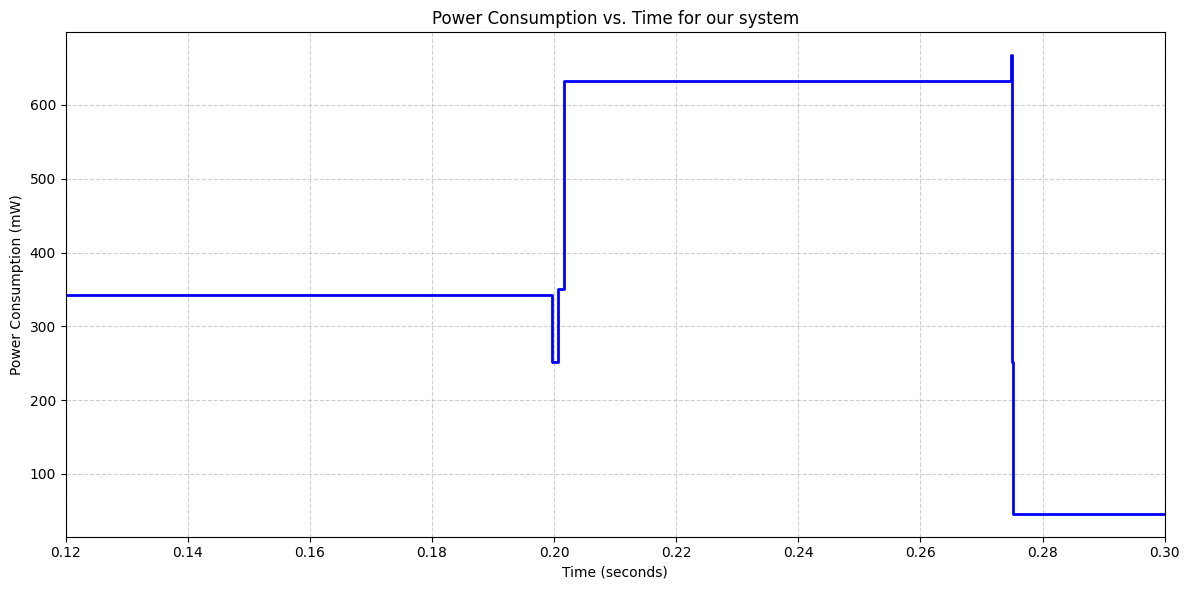

In [42]:
import matplotlib.pyplot as plt

# Assuming variables (boot, sensing, etc.) are defined elsewhere as you mentioned

# Define the sequence
state_sequence = [
    {'name': 'Boot', 'power': boot, 'duration': boot_duration},
    {'name': 'Idle (Wi-Fi OFF - Part 1)', 'power': wifi_off_idle, 'duration': idle_duration_1},
    {'name': 'Sensing', 'power': sensing, 'duration': sensing_duration},
    {'name': 'Wi-Fi On', 'power': wifi_on, 'duration': wifi_on_duration},
    {'name': 'Transmission', 'power': send19, 'duration': transmision_duration},
    {'name': 'Idle (Wi-Fi OFF - Part 2)', 'power': wifi_off_idle, 'duration': idle_duration_2},
    {'name': 'Deep Sleep', 'power': deepsleep, 'duration': deep_sleep_duration},
]

x_coords_plot = []
y_coords_plot = []
current_cumulative_time = 0

# Calculate the end of the active phase (in seconds)
# This includes Boot, Sensing, Wi-Fi On, Transmission, and Idle
active_duration_s = (boot_duration + sensing_duration + wifi_on_duration +
                     transmision_duration + idle_duration) / 1e6

# Convert all durations to SECONDS for a better plot scale
for state in state_sequence:
    # Start of step
    x_coords_plot.append(current_cumulative_time / 1e6)
    y_coords_plot.append(state['power'])

    current_cumulative_time += state['duration']

    # End of step
    x_coords_plot.append(current_cumulative_time / 1e6)
    y_coords_plot.append(state['power'])

plt.figure(figsize=(12, 6))
# Use drawstyle='steps-post' for a cleaner look without markers
plt.plot(x_coords_plot, y_coords_plot, color='blue', linewidth=2, label='Power Consumption')

plt.xlabel('Time (seconds)') # Changed to seconds
plt.ylabel('Power Consumption (mW)')
plt.title('Power Consumption vs. Time for our system')

plt.grid(True, linestyle='--', alpha=0.6)

# --- MODIFIED SECTION ---
# Zoom in on the specific active window from the screenshot
plt.xlim(0.12, 0.30)
# ------------------------

plt.tight_layout()

plt.savefig('Power Consumption vs. Time for our system.png', format='png', bbox_inches='tight')

plt.show()

In this power versus time graph we can clearly see the different phases our system goes through. We start in the boot state, then we go through a first idle phase, which is followed by the sensing phase, which later on is followed by a spike in the power consumption due to the activation of the wifi. Once the wifi is on we transmit the message. After this there is a really small idle phase which is followed by a deep sleep phase. The graph zooms in to see all the different phases.

Now by multipling the duration with the power consumption we'll get the energy consumption for each state.

In [43]:
Energy_boot = (boot_duration * boot)/1000000 #Il consumo del boot è quasi irrilevante
Energy_sensing = (sensing_duration * sensing)/1000000
Energy_wifi_on = (wifi_on_duration * wifi_on)/1000000
Energy_transmission = (transmision_duration * send19)/1000000
Energy_idle = (idle_duration * wifi_off_idle)/1000000
Energy_deep_sleep = (deep_sleep_duration * deepsleep)/1000000

print(f"The energy consumed by the boot state is: {Energy_boot:.2f} mJ")
print(f"The energy consumed by the sensing state is: {Energy_sensing:.2f} mJ")
print(f"The energy consumed by the wifi on state is: {Energy_wifi_on:.2f} mJ")
print(f"The energy consumed by the transmission state is: {Energy_transmission:.2f} mJ")
print(f"The energy consumed by the idle state is: {Energy_idle:.2f} mJ")
print(f"The energy consumed by the deep sleep state is: {Energy_deep_sleep:.2f} mJ")

The energy consumed by the boot state is: 68.46 mJ
The energy consumed by the sensing state is: 0.36 mJ
The energy consumed by the wifi on state is: 46.27 mJ
The energy consumed by the transmission state is: 0.05 mJ
The energy consumed by the idle state is: 0.30 mJ
The energy consumed by the deep sleep state is: 64.09 mJ


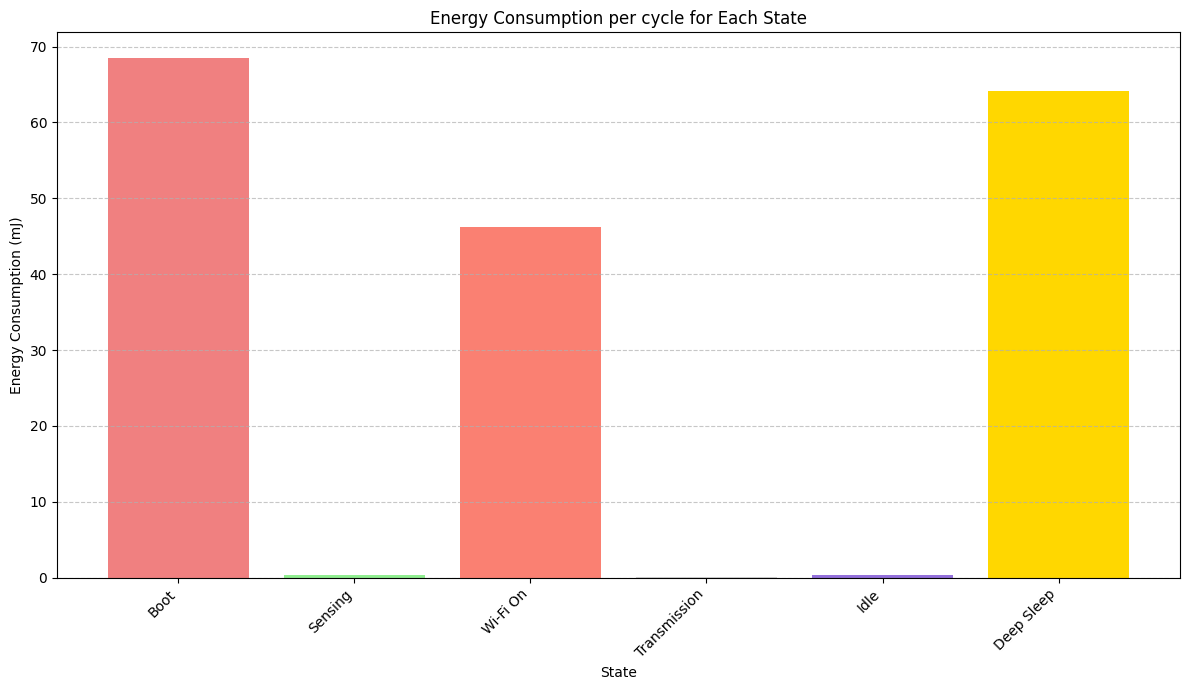

In [44]:
energy_states = [
    'Boot',
    'Sensing',
    'Wi-Fi On',
    'Transmission',
    'Idle',
    'Deep Sleep'
]

energy_consumption_values = [
    Energy_boot,
    Energy_sensing,
    Energy_wifi_on,
    Energy_transmission,
    Energy_idle,
    Energy_deep_sleep
]

plt.figure(figsize=(12, 7))
plt.bar(energy_states, energy_consumption_values, color=['lightcoral', 'lightgreen', 'salmon', 'lightgray', 'mediumpurple', 'gold'])
plt.xlabel('State')
plt.ylabel('Energy Consumption (mJ)')
plt.title('Energy Consumption per cycle for Each State')

plt.savefig('Energy Consumption per cycle for Each State.pdf', format='pdf', bbox_inches='tight')


plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Now we calculate the entire energy consumed by the system during one transmission cycle

In [45]:
Tot_energy = (Energy_boot + Energy_sensing + Energy_wifi_on + Energy_transmission + Energy_idle + Energy_deep_sleep)/1000
print(f"The total energy consumed by the system is {Tot_energy:.3f} J")

The total energy consumed by the system is 0.180 J


Now we estimate the operating lifetime of the sensor node

In [46]:
Battery_energy = 3859%5000+15000
Duty_cycles = Battery_energy / Tot_energy
print(f"It will last for {Duty_cycles:.0f} duty cycles")
Tot_time = (boot_duration + sensing_duration + wifi_on_duration + transmision_duration + idle_duration + deep_sleep_duration)/1000000
Lifetime_duration = Duty_cycles*Tot_time/3600
print(f"It will last for {Lifetime_duration:.3f} h")

It will last for 105047 duty cycles
It will last for 48.879 h


# Possible improvements


A possible improvement is to transmit the reading and signal of the sensors with the minimum power (2dBm) which is clearly possible in a home scenario, mainly if an hop by hop transmission, using bulbs, is implemented since the transmission distance will be small. This will decrease the power consumption of the system, during transmission, passing from 667.41 mW to 617.88 mW.

In [47]:
Energy_transmission_2dBm = (transmision_duration * send2)/1000000
Tot_energy_2dBm =(Energy_boot + Energy_sensing + Energy_wifi_on + Energy_transmission_2dBm + Energy_idle + Energy_deep_sleep)/1000
Duty_cycles_2dBm = Battery_energy / Tot_energy_2dBm
print(f"It will last for {Duty_cycles_2dBm:.0f} duty cycles")
Tot_time = (boot_duration + sensing_duration + wifi_on_duration + transmision_duration + idle_duration + deep_sleep_duration)/1000000
Lifetime_duration_2dBm = Duty_cycles_2dBm*Tot_time/3600
print(f"It will last for {Lifetime_duration_2dBm:.3f} h")

It will last for 105049 duty cycles
It will last for 48.880 h


The improvement in this case is really small since the transmission time is insignificant.

Another possible improvement would be to increase the deep sleep duration. In our case increasing it to 3 seconds is still possible, this would decrease the number of duty cycles performed to 99608 but will increase from 67.47h to 85.64h the lifetime of the system. In our context this would be feasible since the sensing would take place every 3.5/4 seconds.

In [48]:
deep_sleep_duration_2 = 3000000
Energy_deep_sleep_2 = (deep_sleep_duration_2 * deepsleep)/1000000
Tot_energy_2 = (Energy_boot + Energy_sensing + Energy_wifi_on + Energy_transmission + Energy_idle + Energy_deep_sleep_2)/1000
Duty_cycles_2 = Battery_energy / Tot_energy_2
Lifetime_duration_2 = Duty_cycles_2*Tot_time
print(f"It will last for {Duty_cycles_2:.0f} duty cycles")
Tot_time_2 = (boot_duration + sensing_duration + wifi_on_duration + transmision_duration + idle_duration + deep_sleep_duration_2)/1000000
Lifetime_duration_2 = Duty_cycles_2*Tot_time_2/3600
print(f"It will last for {Lifetime_duration_2:.3f} h")

It will last for 74609 duty cycles
It will last for 67.875 h


A significant enhancement involves activating the Wi-Fi module exclusively when message transmission is required. Specifically, the system triggers connectivity only upon the dual condition of low ambient luminosity and detected motion. By integrating this logic into the firmware, overall power efficiency is substantially improved, as it minimizes the duration of the high-energy state associated with active Wi-Fi, one of the most power-intensive components of the system.

Assuming that the sensor is placed in a bathroom that has a window so the luminosity inside the room will be <100 only during nightime and early morning. Plus the fact that a human uses the bathroom in these conditions maximum 10 times a day (we are overestimating just to be sure), the wifi will be activated 10 times a day.

In [49]:
print(f"The total time is: {Tot_time:.3f} seconds")
print(f"The wifi on duration is: {wifi_on_duration:.3f} microseconds")
WiFi_on_Time_per_day = (wifi_on_duration*10)/1000000
print(f"The wifi on duration per day is: {WiFi_on_Time_per_day:.3f} seconds")

The total time is: 1.675 seconds
The wifi on duration is: 73206.750 microseconds
The wifi on duration per day is: 0.732 seconds


Since the wifi is on for 73206.750 microseconds each cycle this means it will be active for (73206.750*10)/1000000= 0,732 seconds per day. Given that the lifetime of the system was 48. 879 hours, this means the wi-fi will be on for 1.49 seconds before the system shuts down, which consists of 0.0008467% of the system's lifetime. (We assumed the inital conditions so a transmission at 19.5 dBm and a deep sleep of 1.4 seconds)

In [50]:
Tot_wifi_on_time = (105047*73206.750)/1000000
print(f"The total wifi on duration is: {Tot_wifi_on_time:.3f} seconds")

The total wifi on duration is: 7690.149 seconds


Given that before the wifi was on at each cycle, it was on for 7690.149 seconds. This means it was on for 4.37% of the time, always assuming a deep sleep of 1.4 seconds.

This means we passed from having the wifi on for 4.37% of the lifetime of the system to 0.0008467% of the lifetime. In terms of energy consumed, given that the wifi_on phase consumes 632.04 mW this brought us from a consumption of 4860.5 J to 0.942 J, which consists in a saving of 99.98% of the wifi energy.

"By implementing conditional logic—requiring both low luminosity and motion detection—we have transformed the Wi-Fi module from a constant drain into an event-driven tool. We have effectively decoupled the system's lifespan from the clock and tied it to actual usage. Since the Wi-Fi is active for less than a second per day total, the battery is no longer 'powering a radio,' it's 'powering a sensor that occasionally uses a radio.'

To prevent the case in which the system doesn't send any message and might seem it isn't working, an implementation that every 100 boots sends a message signaling the system is still alive would be great. In this way when no message is received we are sure the system life ha come to an end and an intervention is required.

To prevent "silent failure," we propose a "heartbeat" mechanism where the system sends a status message every 100 boot cycles regardless of sensor triggers. Since a lack of data could currently mean either an empty room or a dead battery, this proactive signal confirms the device is still functional. In a physical deployment, this would utilize RTC memory to maintain a persistent counter through deep sleep. By accepting a negligible 1% transmission overhead, we gain total visibility into the system's health, ensuring it remains a reliable monitoring tool even during long periods of inactivity.